Using device: cuda
Train size: 50000
Dev size: 10000
Test size: 29493
Classes: ['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']
0|0.00|The emergence of HIV as a chronic condition means that people living with HIV are required to take more responsibility for the self-management of their condition , including making physical , emotional and social adjustments .
0|0.09|This paper describes the design and evaluation of Positive Outlook , an online program aiming to enhance the self-management skills of gay men living with HIV .
2|0.18|This study is designed as a randomised controlled trial in which men living with HIV in Australia will be assigned to either an intervention group or usual care control group .
2|0.27|The intervention group will participate in the online group program ` Positive Outlook ' .
2|0.36|The program is based on self-efficacy theory and uses a self-management approach to enhance skills , confidence and abilities to manage the psychosocial issues assoc

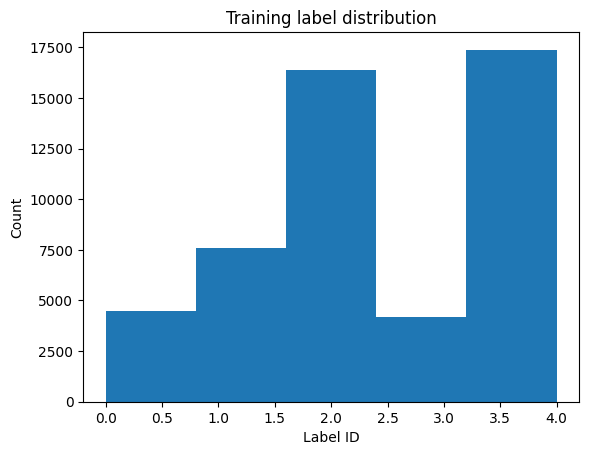

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import os
Results_folder=r"C:\Users\user\Desktop\PubMed-RCT-Classification-Transformer\Results"
#device
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)
#dataset paths
data_path=r"C:\Users\user\Desktop\PubMed-RCT-Classification-Transformer\Data\PubMed_200k_RCT"
train_path=os.path.join(data_path,"train.txt")
dev_path=os.path.join(data_path,"dev.txt")
test_path=os.path.join(data_path,"test.txt")

#loading data
def load_pubmed_file(path):
    texts,labels,positions=[],[],[]
    abstract=[]
    with open(path,"r",encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if line.startswith("###"):
                abstract=[]
            elif line=="":
                if len(abstract)>0:
                    total=len(abstract)
                    for i,(label,sentence) in enumerate(abstract):
                        texts.append(sentence)
                        labels.append(label)
                        positions.append(i/total)
                abstract=[]
            else:
                label,sentence=line.split("\t")
                abstract.append((label,sentence))
    return texts,labels,positions
train_texts,train_labels,train_positions=load_pubmed_file(train_path)
dev_texts,dev_labels,dev_positions=load_pubmed_file(dev_path)
test_texts,test_labels,test_positions=load_pubmed_file(test_path)
train_texts=train_texts[:50000]
train_labels=train_labels[:50000]
dev_texts=dev_texts[:10000]
dev_labels=dev_labels[:10000]
#label encoding
unique_labels=sorted(list(set(train_labels)))
label_to_id={l:i for i,l in enumerate(unique_labels)}
train_labels=[label_to_id[l] for l in train_labels]
dev_labels=[label_to_id[l] for l in dev_labels]
test_labels=[label_to_id[l] for l in test_labels]
#quickinspection
print("Train size:", len(train_texts))
print("Dev size:", len(dev_texts))
print("Test size:", len(test_texts))
print("Classes:", unique_labels)
#sample sentences
for i in range(5):
    print(f"{train_labels[i]}|{train_positions[i]:.2f}|{train_texts[i]}")
#plot
plt.hist(train_labels, bins=len(unique_labels))
plt.title("Training label distribution")
plt.xlabel("Label ID")
plt.ylabel("Count")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_29040\3964281462.py:64: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler()
C:\Users\user\AppData\Local\Temp\ipykernel_29040\3964281462.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch1|Loss:1.0763|Dev Acc:0.7425
Epoch2|Loss:0.6506|Dev Acc:0.7742
Epoch3|Loss:0.5685|Dev Acc:0.7771
Epoch4|Loss:0.5083|Dev Acc:0.7846
Epoch5|Loss:0.4580|Dev Acc:0.7827
Epoch6|Loss:0.4194|Dev Acc:0.7843
Epoch7|Loss:0.3799|Dev Acc:0.7756
Epoch8|Loss:0.3442|Dev Acc:0.7848
Epoch9|Loss:0.3161|Dev Acc:0.7790
Epoch10|Loss:0.2886|Dev Acc:0.7796
Base model saved!


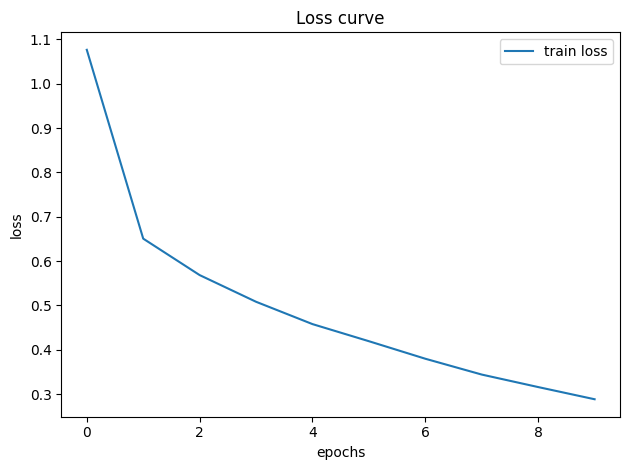

In [22]:
#basic model
class seq2seqtransformer(nn.Module):
    def __init__(self,src_vocab_size,tgt_vocab_size,d_model,num_heads,num_layers,max_len=100):
        super().__init__()
        self.src_embed=nn.Embedding(src_vocab_size,d_model)
        self.tgt_embed=nn.Embedding(tgt_vocab_size,d_model)
        self.src_pos=nn.Embedding(max_len,d_model)
        self.tgt_pos=nn.Embedding(max_len,d_model)
        encoder_layer=nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            batch_first=True
        )
        self.encoder=nn.TransformerEncoder(encoder_layer,num_layers)
        decoder_layer=nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            batch_first=True
        )
        self.decoder=nn.TransformerDecoder(decoder_layer,num_layers)
        self.fc_out=nn.Linear(d_model,tgt_vocab_size)
    def forward(self,src,tgt):
        batch_size,src_len=src.shape
        batch_size,tgt_len=tgt.shape
        #positions
        src_pos=torch.arange(src_len,device=src.device).unsqueeze(0).expand(batch_size,src_len)
        tgt_pos=torch.arange(tgt_len,device=tgt.device).unsqueeze(0).expand(batch_size,tgt_len)
        #embed+pos
        src=self.src_embed(src)+self.src_pos(src_pos)
        tgt=self.tgt_embed(tgt)+self.tgt_pos(tgt_pos)
        memory=self.encoder(src)
        #causal mask decoder
        tgt_mask=torch.triu(torch.ones(tgt_len,tgt_len),diagonal=1)
        tgt_mask=tgt_mask.masked_fill(tgt_mask==1,float('-inf')).to(tgt.device)
        #decoder self attn and cross attn
        out=self.decoder(tgt,memory,tgt_mask=tgt_mask)
        return self.fc_out(out)
#tokenization
words=set(word for sent in train_texts for word in sent.split())
src_vocab={w:i for i,w in enumerate(words)}
tgt_vocab=src_vocab
src_vocab_size=len(src_vocab)
tgt_vocab_size=len(tgt_vocab)
max_len=50
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size=len(src_vocab)+1
num_classes=len(set(train_labels))
base_model=seq2seqtransformer(vocab_size,vocab_size,d_model=32,num_heads=2,num_layers=2).to(device)
#creating tensors,conversion to long tensors
train_src = torch.tensor([[src_vocab.get(w,0) for w in sent.split()[:max_len]]+[0]*(max_len-len(sent.split()[:max_len])) for sent in train_texts],dtype=torch.long)
dev_src=torch.tensor([[src_vocab.get(w,0) for w in sent.split()[:max_len]]+[0]*(max_len-len(sent.split()[:max_len])) for sent in dev_texts],dtype=torch.long)
train_labels=torch.tensor(train_labels,dtype=torch.long)
dev_labels=torch.tensor(dev_labels,dtype=torch.long)
base_optimizer=torch.optim.Adam(base_model.parameters(),lr=1e-3)
criterion=nn.CrossEntropyLoss()

#dataset and dataloader
train_dataset=TensorDataset(train_src,train_labels)
dev_dataset=TensorDataset(dev_src,dev_labels)
batch_size=16
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
dev_loader=DataLoader(dev_dataset,batch_size=batch_size,shuffle=False)
#training loop
scaler=GradScaler()
base_losses=[]
epochs=10
for epoch in range(epochs):
    base_model.train()
    epoch_loss=0
    for batch_src,batch_labels in train_loader:
        batch_src, batch_labels=batch_src.to(device),batch_labels.to(device)
        base_optimizer.zero_grad()        
        with autocast():
            memory=base_model.encoder(base_model.src_embed(batch_src))
            logits=base_model.fc_out(memory[:,0,:])
            loss=criterion(logits,batch_labels)        
        scaler.scale(loss).backward()
        scaler.step(base_optimizer)
        scaler.update()        
        epoch_loss+=loss.item()
    base_losses.append(epoch_loss/len(train_loader))
    #validation/dev accuracy
    base_model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for batch_src,batch_labels in dev_loader:
            batch_src,batch_labels=batch_src.to(device),batch_labels.to(device)
            memory=base_model.encoder(base_model.src_embed(batch_src))
            logits=base_model.fc_out(memory[:, 0, :])
            preds=logits.argmax(dim=-1)
            correct+=(preds==batch_labels).sum().item()
            total+=batch_labels.size(0)
    acc=correct/total
    base_model.train()    
    print(f"Epoch{epoch+1}|Loss:{base_losses[-1]:.4f}|Dev Acc:{acc:.4f}")
torch.save(base_model.state_dict(), os.path.join(Results_folder, "base_model.pth"))
print("Base model saved!")
#visualisation
plt.plot(base_losses, label="train loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("Loss curve")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"base_model_train_loss.png"))
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_29040\386840858.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels_tensor=torch.tensor(train_labels, dtype=torch.long)
C:\Users\user\AppData\Local\Temp\ipykernel_29040\386840858.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dev_labels_tensor=torch.tensor(dev_labels,dtype=torch.long)
C:\Users\user\AppData\Local\Temp\ipykernel_29040\386840858.py:64: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler=GradScaler()


epoch1|loss:1.0786|dev acc: 0.7504
epoch2|loss:0.6500|dev acc: 0.7725
epoch3|loss:0.5672|dev acc: 0.7755
epoch4|loss:0.5078|dev acc: 0.7849
epoch5|loss:0.4603|dev acc: 0.7919
epoch6|loss:0.4166|dev acc: 0.7839
epoch7|loss:0.3792|dev acc: 0.7854
epoch8|loss:0.3472|dev acc: 0.7820
epoch9|loss:0.3127|dev acc: 0.7779
epoch10|loss:0.2836|dev acc: 0.7739


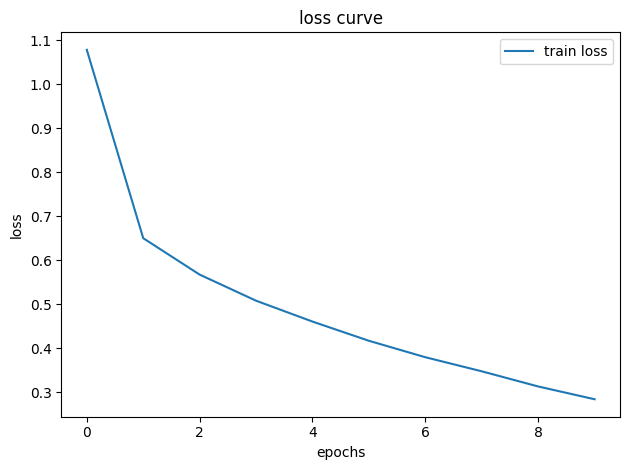

In [23]:
#optimized model
class OptimizedTransformer(nn.Module):
    def __init__(self,src_vocab_size,tgt_vocab_size,d_model=32,num_heads=2,num_layers=2,max_len=50,dropout=0.1):
        super().__init__()
        self.src_embed=nn.Embedding(src_vocab_size,d_model)
        self.tgt_embed=nn.Embedding(tgt_vocab_size,d_model)
        self.src_pos=nn.Embedding(max_len, d_model)
        self.tgt_pos=nn.Embedding(max_len, d_model)
        encoder_layer=nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            batch_first=True,
            dropout=dropout
            )
        self.encoder=nn.TransformerEncoder(encoder_layer, num_layers)
        decoder_layer=nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            batch_first=True,
            dropout=dropout)
        self.decoder=nn.TransformerDecoder(decoder_layer, num_layers)
        self.fc_out=nn.Linear(d_model, tgt_vocab_size)
        self.layer_norm=nn.LayerNorm(d_model)
        self.dropout=nn.Dropout(dropout)

    def forward(self,src,tgt):
        batch_size,src_len=src.shape
        _,tgt_len=tgt.shape
        src_pos=torch.arange(src_len,device=src.device).unsqueeze(0).expand(batch_size,src_len)
        tgt_pos=torch.arange(tgt_len,device=tgt.device).unsqueeze(0).expand(batch_size,tgt_len)
        src=self.dropout(self.layer_norm(self.src_embed(src)+self.src_pos(src_pos)))
        tgt=self.dropout(self.layer_norm(self.tgt_embed(tgt)+self.tgt_pos(tgt_pos)))
        memory = self.encoder(src)
        tgt_mask=torch.triu(torch.ones(tgt_len,tgt_len,device=src.device),diagonal=1)
        tgt_mask=tgt_mask.masked_fill(tgt_mask==1,float('-inf'))
        out=self.decoder(tgt,memory,tgt_mask=tgt_mask)
        return self.fc_out(out)

#tokenixation
words=set(word for sent in train_texts for word in sent.split())
src_vocab={w:i for i,w in enumerate(words)}
tgt_vocab=src_vocab
vocab_size=len(src_vocab) + 1
num_classes=len(set(train_labels))
max_len=50
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=OptimizedTransformer(vocab_size,vocab_size,d_model=32,num_heads=2,num_layers=2,max_len=max_len).to(device)
#txt to tensor conversion
train_src=torch.tensor([[src_vocab.get(w,0) for w in sent.split()[:max_len]]+[0]*(max_len-len(sent.split()[:max_len])) for sent in train_texts],dtype=torch.long)
dev_src=torch.tensor([[src_vocab.get(w,0) for w in sent.split()[:max_len]] +[0]*(max_len-len(sent.split()[:max_len])) for sent in dev_texts],dtype=torch.long)
train_labels_tensor=torch.tensor(train_labels, dtype=torch.long)
dev_labels_tensor=torch.tensor(dev_labels,dtype=torch.long)

optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
criterion=nn.CrossEntropyLoss()
#dataloader and dataset
batch_size=16
train_dataset=TensorDataset(train_src,train_labels_tensor)
dev_dataset=TensorDataset(dev_src,dev_labels_tensor)
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
dev_loader=DataLoader(dev_dataset,batch_size=batch_size,shuffle=False)

#training loop
scaler=GradScaler()
losses=[]
epochs=10
for epoch in range(epochs):
    model.train()
    epoch_loss=0
    for batch_src,batch_labels in train_loader:
        batch_src,batch_labels=batch_src.to(device),batch_labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            memory=model.encoder(model.src_embed(batch_src))
            logits=model.fc_out(memory[:,0,:])
            loss=criterion(logits, batch_labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss+=loss.item()
    losses.append(epoch_loss/len(train_loader))
    
    #validation
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for batch_src,batch_labels in dev_loader:
            batch_src,batch_labels=batch_src.to(device),batch_labels.to(device)
            memory=model.encoder(model.src_embed(batch_src))
            logits=model.fc_out(memory[:,0,:])
            preds=logits.argmax(dim=-1)
            correct+=(preds == batch_labels).sum().item()
            total+=batch_labels.size(0)
    acc=correct/total
    model.train()
    print(f"epoch{epoch+1}|loss:{losses[-1]:.4f}|dev acc: {acc:.4f}")

#visualisation
plt.plot(losses,label="train loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("loss curve")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"optimized_model_train_loss.png"))
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_29040\3400733262.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  base_model_eval.load_state_dict(torch.load(os.path.join(Resu

Base model dev ccuracy:0.7796
Optimized model dev accuracy:0.7739


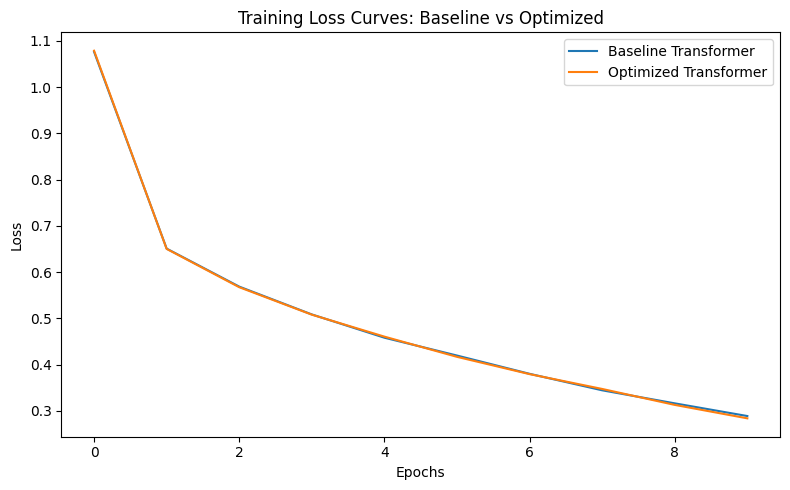

<Figure size 800x600 with 0 Axes>

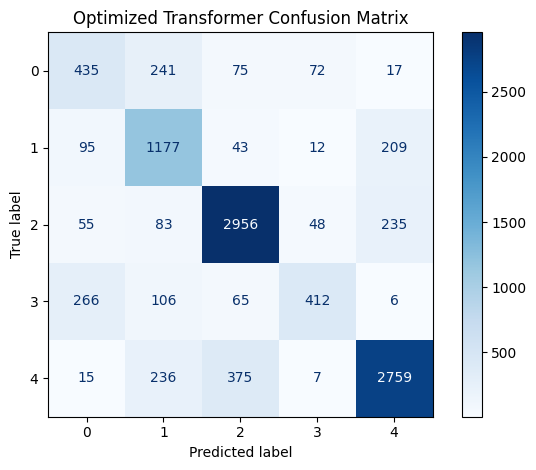

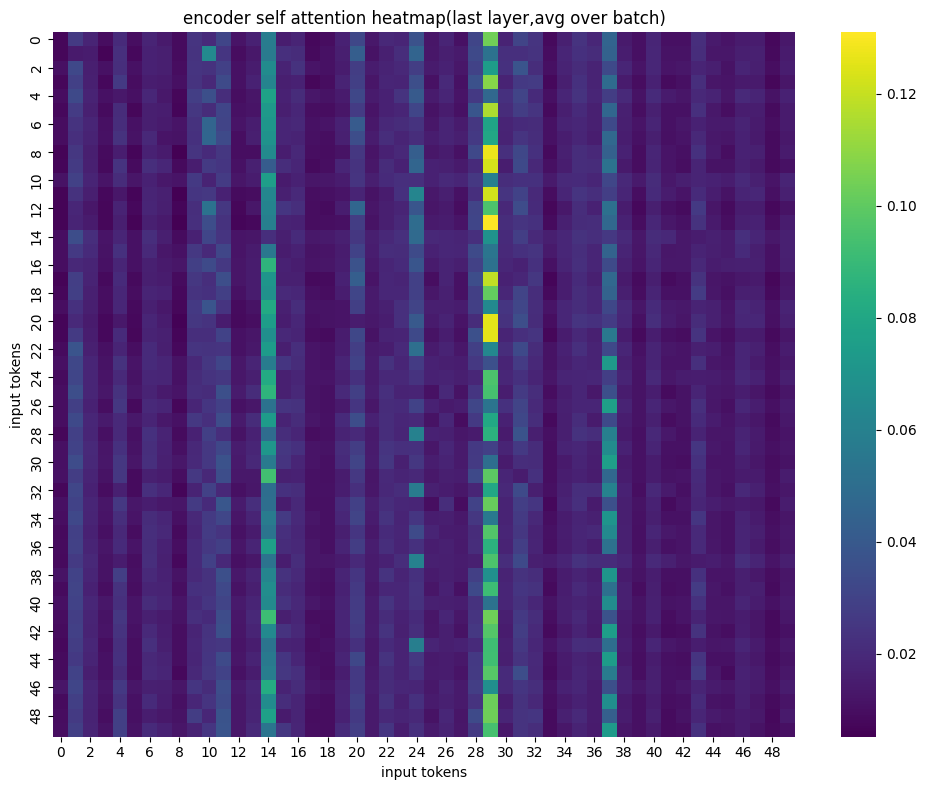

In [24]:
#comparision and visualisation
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def evaluate_model(model,loader):
    model.eval()
    correct=0
    total=0
    all_preds=[]
    all_labels=[]
    with torch.no_grad():
        for batch_src,batch_labels in loader:
            batch_src,batch_labels=batch_src.to(device),batch_labels.to(device)
            memory=model.encoder(model.src_embed(batch_src))
            logits=model.fc_out(memory[:,0,:])
            preds=logits.argmax(dim=-1)
            correct+=(preds==batch_labels).sum().item()
            total+=batch_labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
    acc=correct/total
    return acc,all_preds,all_labels

#base model eval
base_model_eval=seq2seqtransformer(vocab_size,vocab_size,d_model=32,num_heads=2,num_layers=2).to(device)
base_model_eval.load_state_dict(torch.load(os.path.join(Results_folder,"base_model.pth")))
base_acc,base_preds,base_true=evaluate_model(base_model_eval,dev_loader)

#optimzed model eval
opt_acc,opt_preds,opt_labels=evaluate_model(model,dev_loader)
print(f"Base model dev ccuracy:{base_acc:.4f}")
print(f"Optimized model dev accuracy:{opt_acc:.4f}")

#loss curve plots
plt.figure(figsize=(8,5))
plt.plot(base_losses,label="Baseline Transformer")
plt.plot(losses,label="Optimized Transformer") 
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curves: Baseline vs Optimized")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"loss_curves.png"))
plt.show()

#confusion matrix optimized nodel
cm=confusion_matrix(opt_labels, opt_preds)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(8,6))
disp.plot(cmap=plt.cm.Blues)
plt.title("Optimized Transformer Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"confusion_matrix.png"))
plt.show()

#attention heatmap
sample_batch=next(iter(dev_loader))[0][:5].to(device)#1st 5 sentences
model.eval()
with torch.no_grad():
    src_pos=torch.arange(sample_batch.shape[1],device=device).unsqueeze(0).expand(sample_batch.shape[0],sample_batch.shape[1])
    src_embed=model.dropout(model.layer_norm(model.src_embed(sample_batch)+model.src_pos(src_pos)))
    attn_weights_list=[]
    out=src_embed
    for layer in model.encoder.layers:
        out,attn_weights=layer.self_attn(out,out,out,need_weights=True)
        attn_weights_list.append(attn_weights)
        out=layer.dropout2(layer.norm2(layer.linear2(layer.dropout(layer.activation(layer.linear1(out))))+out))#feedforward + residual
#avg attn
attn_avg=attn_weights_list[-1].mean(0).cpu().numpy()
plt.figure(figsize=(10,8))
sns.heatmap(attn_avg,cmap="viridis")
plt.xlabel("input tokens")
plt.ylabel("input tokens")
plt.title("encoder self attention heatmap(last layer,avg over batch)")
plt.tight_layout()
plt.savefig(os.path.join(Results_folder,"heatmap.png"))
plt.show()

In [30]:
#what did model do?
model.eval()
id_to_label = {v:k for k,v in label_to_id.items()}

print("predictions")
for idx in range(10):
    sentence=dev_texts[idx]
    true_label=id_to_label[dev_labels[idx].item()]
    
    tokens=[src_vocab.get(w,0) for w in sentence.split()[:max_len]]
    tokens+=[0]*(max_len-len(tokens))
    src_tensor=torch.tensor([tokens],dtype=torch.long).to(device)
    with torch.no_grad():
        memory=model.encoder(model.src_embed(src_tensor))
        logits=model.fc_out(memory[:,0,:])
        pred=id_to_label[logits.argmax().item()]
    
    status="Prediction is" if pred==true_label else "prediction is not"
    print(f"{status} true:{true_label:<15} pred:{pred:<15}")
    print(f"\"{sentence[:60]}...\"")
    print()

predictions
prediction is not true:BACKGROUND      pred:CONCLUSIONS    
"Adrenergic activation is thought to be an important determin..."

prediction is not true:RESULTS         pred:METHODS        
"Systemic venous norepinephrine was measured at baseline , 3 ..."

Prediction is true:RESULTS         pred:RESULTS        
"Baseline norepinephrine level was associated with a progress..."

Prediction is true:RESULTS         pred:RESULTS        
"On multivariate analysis , baseline norepinephrine was also ..."

prediction is not true:RESULTS         pred:CONCLUSIONS    
"In contrast , the relation of the change in norepinephrine a..."

Prediction is true:RESULTS         pred:RESULTS        
"In the placebo-treated group but not in the bucindolol-treat..."

Prediction is true:RESULTS         pred:RESULTS        
"In the bucindolol-treated group but not in the placebo-treat..."

Prediction is true:RESULTS         pred:RESULTS        
"A likelihood-based method indicated that 18 % of the bucin